In [1]:
import sys
import pandas as pd

print("Python path:", sys.executable)
print("Pandas version:", pd.__version__)


Python path: /home/sengul/projects/icu-risk-prediction/.venv/bin/python
Pandas version: 3.0.5


In [2]:
patients_df = pd.read_csv(
    "/mnt/c/Users/vetts/Downloads/MimicIII/"
    "mimic-iii-clinical-database-1.4/PATIENTS.csv/PATIENTS.csv"
)

patients_df.head()

,ROW_ID,SUBJECT_ID,GENDER,DOB,DOD,DOD_HOSP,DOD_SSN,EXPIRE_FLAG
0,234,249,F,2075-03-13 00:00:00,NaN,NaN,NaN,0
1,235,250,F,2164-12-27 00:00:00,2188-11-22 00:00:00,2188-11-22 00:00:00,NaN,1
2,236,251,M,2090-03-15 00:00:00,NaN,NaN,NaN,0
3,237,252,M,2078-03-06 00:00:00,NaN,NaN,NaN,0
4,238,253,F,2089-11-26 00:00:00,NaN,NaN,NaN,0


In [3]:
print("Rows and columns:", patients_df.shape)

patients_df.info()

Rows and columns: (46520, 8)
<class 'pandas.DataFrame'>
RangeIndex: 46520 entries, 0 to 46519
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ROW_ID       46520 non-null  int64
 1   SUBJECT_ID   46520 non-null  int64
 2   GENDER       46520 non-null  str  
 3   DOB          46520 non-null  str  
 4   DOD          15759 non-null  str  
 5   DOD_HOSP     9974 non-null   str  
 6   DOD_SSN      13378 non-null  str  
 7   EXPIRE_FLAG  46520 non-null  int64
dtypes: int64(3), str(5)
memory usage: 4.5 MB


In [4]:
admissions_df = pd.read_csv(
    "/mnt/c/Users/vetts/Downloads/MimicIII/"
    "mimic-iii-clinical-database-1.4/ADMISSIONS.csv/ADMISSIONS.csv"
)

print("Rows and columns:", admissions_df.shape)
admissions_df.info()

Rows and columns: (58976, 19)
<class 'pandas.DataFrame'>
RangeIndex: 58976 entries, 0 to 58975
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ROW_ID                58976 non-null  int64
 1   SUBJECT_ID            58976 non-null  int64
 2   HADM_ID               58976 non-null  int64
 3   ADMITTIME             58976 non-null  str  
 4   DISCHTIME             58976 non-null  str  
 5   DEATHTIME             5854 non-null   str  
 6   ADMISSION_TYPE        58976 non-null  str  
 7   ADMISSION_LOCATION    58976 non-null  str  
 8   DISCHARGE_LOCATION    58976 non-null  str  
 9   INSURANCE             58976 non-null  str  
 10  LANGUAGE              33644 non-null  str  
 11  RELIGION              58518 non-null  str  
 12  MARITAL_STATUS        48848 non-null  str  
 13  ETHNICITY             58976 non-null  str  
 14  EDREGTIME             30877 non-null  str  
 15  EDOUTTIME             30877 non-nu

In [5]:
admissions_df.head()

,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2196-04-09 10:06:00,2196-04-09 13:24:00,BENZODIAZEPINE OVERDOSE,0,1
1,22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,NaN,NaN,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0,1
2,23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,NaN,NaN,BRAIN MASS,0,1
3,24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,NaN,NaN,INTERIOR MYOCARDIAL INFARCTION,0,1
4,25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2160-11-02 01:01:00,2160-11-02 04:27:00,ACUTE CORONARY SYNDROME,0,1


In [6]:
admissions_df.head().T

,0,1,2,3,4
ROW_ID,21,22,23,24,25
SUBJECT_ID,22,23,23,24,25
HADM_ID,165315,152223,124321,161859,129635
ADMITTIME,2196-04-09 12:26:00,2153-09-03 07:15:00,2157-10-18 19:34:00,2139-06-06 16:14:00,2160-11-02 02:06:00
DISCHTIME,2196-04-10 15:54:00,2153-09-08 19:10:00,2157-10-25 14:00:00,2139-06-09 12:48:00,2160-11-05 14:55:00
DEATHTIME,NaN,NaN,NaN,NaN,NaN
ADMISSION_TYPE,EMERGENCY,ELECTIVE,EMERGENCY,EMERGENCY,EMERGENCY
ADMISSION_LOCATION,EMERGENCY ROOM ADMIT,PHYS REFERRAL/NORMAL DELI,TRANSFER FROM HOSP/EXTRAM,TRANSFER FROM HOSP/EXTRAM,EMERGENCY ROOM ADMIT
DISCHARGE_LOCATION,DISC-TRAN CANCER/CHLDRN H,HOME HEALTH CARE,HOME HEALTH CARE,HOME,HOME
INSURANCE,Private,Medicare,Medicare,Private,Private


In [7]:
icustays_df = pd.read_csv(
    "/mnt/c/Users/vetts/Downloads/MimicIII/"
    "mimic-iii-clinical-database-1.4/ICUSTAYS.csv/ICUSTAYS.csv"
)

print("Rows and columns:", icustays_df.shape)
icustays_df.info()

Rows and columns: (61532, 12)
<class 'pandas.DataFrame'>
RangeIndex: 61532 entries, 0 to 61531
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ROW_ID          61532 non-null  int64  
 1   SUBJECT_ID      61532 non-null  int64  
 2   HADM_ID         61532 non-null  int64  
 3   ICUSTAY_ID      61532 non-null  int64  
 4   DBSOURCE        61532 non-null  str    
 5   FIRST_CAREUNIT  61532 non-null  str    
 6   LAST_CAREUNIT   61532 non-null  str    
 7   FIRST_WARDID    61532 non-null  int64  
 8   LAST_WARDID     61532 non-null  int64  
 9   INTIME          61532 non-null  str    
 10  OUTTIME         61522 non-null  str    
 11  LOS             61522 non-null  float64
dtypes: float64(1), int64(6), str(5)
memory usage: 8.8 MB


In [8]:
icustays_df.head().T

,0,1,2,3,4
ROW_ID,365,366,367,368,369
SUBJECT_ID,268,269,270,271,272
HADM_ID,110404,106296,188028,173727,164716
ICUSTAY_ID,280836,206613,220345,249196,210407
DBSOURCE,carevue,carevue,carevue,carevue,carevue
FIRST_CAREUNIT,MICU,MICU,CCU,MICU,CCU
LAST_CAREUNIT,MICU,MICU,CCU,SICU,CCU
FIRST_WARDID,52,52,57,52,57
LAST_WARDID,52,52,57,23,57
INTIME,2198-02-14 23:27:38,2170-11-05 11:05:29,2128-06-24 15:05:20,2120-08-07 23:12:42,2186-12-25 21:08:04


# 01 — Data Overview

## Objective
Explore the core tables for an ICU risk prediction project.

## Environment
Created a project-specific Python environment and verified pandas.

## Tables Reviewed
- PATIENTS: 46,520 rows and 8 columns.
- ADMISSIONS: 58,976 rows and 19 columns.
- ICUSTAYS: 61,532 rows and 12 columns.

## Initial Findings
- SUBJECT_ID identifies a patient.
- HADM_ID identifies a hospital admission.
- ICUSTAY_ID identifies an ICU stay.
- A patient can have multiple admissions.
- Date columns were loaded as strings.
- OUTTIME and LOS each have 10 missing values in ICUSTAYS.
- LOS represents ICU length of stay in days.

## Core Table Merge
Created icu_base_df with one row per ICU stay.

- Checked the primary identifiers for missing values and duplicates.
- Combined selected columns using validated left joins.
- Preserved all 61,532 ICU stays.
- The merged table contains 13 columns.
- Every ICU stay matched a patient and hospital admission.
- The original DataFrames were kept unchanged.

In [9]:
for name, df, key in [
    ("PATIENTS", patients_df, "SUBJECT_ID"),
    ("ADMISSIONS", admissions_df, "HADM_ID"),
    ("ICUSTAYS", icustays_df, "ICUSTAY_ID"),
]:
    print(
        name,
        "| Missing IDs:", df[key].isna().sum(),
        "| Duplicate IDs:", df[key].duplicated().sum()
    )

PATIENTS | Missing IDs: 0 | Duplicate IDs: 0
ADMISSIONS | Missing IDs: 0 | Duplicate IDs: 0
ICUSTAYS | Missing IDs: 0 | Duplicate IDs: 0


In [10]:
print(
    "ICU rows without a patient match:",
    (~icustays_df["SUBJECT_ID"].isin(patients_df["SUBJECT_ID"])).sum()
)

print(
    "ICU rows without an admission match:",
    (~icustays_df["HADM_ID"].isin(admissions_df["HADM_ID"])).sum()
)


ICU rows without a patient match: 0
ICU rows without an admission match: 0


In [11]:
# 1. Select the required ICU stay columns
icu_base_df = icustays_df[
    [
        "SUBJECT_ID", "HADM_ID", "ICUSTAY_ID",
        "INTIME", "OUTTIME", "FIRST_CAREUNIT", "LOS"
    ]
].copy()

# 2. Add patient information
icu_base_df = icu_base_df.merge(
    patients_df[["SUBJECT_ID", "GENDER", "DOB"]],
    on="SUBJECT_ID",
    how="left",
    validate="many_to_one"
)

# 3. Add hospital admission information
icu_base_df = icu_base_df.merge(
    admissions_df[
        [
            "SUBJECT_ID", "HADM_ID",
            "ADMITTIME", "DISCHTIME",
            "ADMISSION_TYPE", "HOSPITAL_EXPIRE_FLAG"
        ]
    ],
    on=["SUBJECT_ID", "HADM_ID"],
    how="left",
    validate="many_to_one"
)

print("Merged table shape:", icu_base_df.shape)

Merged table shape: (61532, 13)


In [12]:
icu_base_df.head().T

,0,1,2,3,4
SUBJECT_ID,268,269,270,271,272
HADM_ID,110404,106296,188028,173727,164716
ICUSTAY_ID,280836,206613,220345,249196,210407
INTIME,2198-02-14 23:27:38,2170-11-05 11:05:29,2128-06-24 15:05:20,2120-08-07 23:12:42,2186-12-25 21:08:04
OUTTIME,2198-02-18 05:26:11,2170-11-08 17:46:57,2128-06-27 12:32:29,2120-08-10 00:39:04,2186-12-27 12:01:13
FIRST_CAREUNIT,MICU,MICU,CCU,MICU,CCU
LOS,3.249,3.2788,2.8939,2.06,1.6202
GENDER,F,M,M,F,M
DOB,2132-02-21 00:00:00,2130-09-30 00:00:00,2048-05-26 00:00:00,2074-11-30 00:00:00,2119-11-21 00:00:00
ADMITTIME,2198-02-11 13:40:00,2170-11-05 11:04:00,2128-06-23 18:26:00,2120-08-07 18:56:00,2186-12-25 21:06:00


In [13]:
icu_base_df.head()

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,INTIME,OUTTIME,FIRST_CAREUNIT,LOS,GENDER,DOB,ADMITTIME,DISCHTIME,ADMISSION_TYPE,HOSPITAL_EXPIRE_FLAG
0,268,110404,280836,2198-02-14 23:27:38,2198-02-18 05:26:11,MICU,3.2490,F,2132-02-21 00:00:00,2198-02-11 13:40:00,2198-02-18 03:55:00,EMERGENCY,1
1,269,106296,206613,2170-11-05 11:05:29,2170-11-08 17:46:57,MICU,3.2788,M,2130-09-30 00:00:00,2170-11-05 11:04:00,2170-11-27 18:00:00,EMERGENCY,0
2,270,188028,220345,2128-06-24 15:05:20,2128-06-27 12:32:29,CCU,2.8939,M,2048-05-26 00:00:00,2128-06-23 18:26:00,2128-06-27 12:31:00,ELECTIVE,0
3,271,173727,249196,2120-08-07 23:12:42,2120-08-10 00:39:04,MICU,2.0600,F,2074-11-30 00:00:00,2120-08-07 18:56:00,2120-08-20 16:00:00,EMERGENCY,0
4,272,164716,210407,2186-12-25 21:08:04,2186-12-27 12:01:13,CCU,1.6202,M,2119-11-21 00:00:00,2186-12-25 21:06:00,2187-01-02 14:57:00,EMERGENCY,0


In [14]:
print("Missing patient matches:", icu_base_df["DOB"].isna().sum())
print("Missing admission matches:", icu_base_df["ADMITTIME"].isna().sum())

Missing patient matches: 0
Missing admission matches: 0


## Core Table Merge

Selected columns from PATIENTS, ADMISSIONS, and ICUSTAYS were
combined into `icu_base_df`, with one row per ICU stay.

- Checked identifiers for missing values and duplicates.
- Used left joins with many-to-one validation.
- Preserved all 61,532 ICU stays, producing 13 columns.
- Confirmed that every ICU stay matched a patient and hospital admission.
- Kept the original DataFrames unchanged.

In [15]:
date_columns = [
    "DOB", "ADMITTIME", "DISCHTIME", "INTIME", "OUTTIME"
]

for column in date_columns:
    icu_base_df[column] = pd.to_datetime(
        icu_base_df[column],
        errors="raise"
    )

icu_base_df[date_columns].dtypes

DOB          datetime64[us]
ADMITTIME    datetime64[us]
DISCHTIME    datetime64[us]
INTIME       datetime64[us]
OUTTIME      datetime64[us]
dtype: object

In [16]:
icu_base_df["AGE_RAW"] = (
    (icu_base_df["INTIME"] - icu_base_df["DOB"])
    .dt.total_seconds()
    / (365.25 * 24 * 60 * 60)
)

icu_base_df["AGE_RAW"].describe()

count    61532.000000
mean        64.887908
std         56.913140
min          0.000007
25%         44.349735
50%         62.073695
75%         76.057137
max        311.554203
Name: AGE_RAW, dtype: float64

In [17]:
icu_base_df["AGE_RAW"].describe()

count    61532.000000
mean        64.887908
std         56.913140
min          0.000007
25%         44.349735
50%         62.073695
75%         76.057137
max        311.554203
Name: AGE_RAW, dtype: float64

In [18]:
icu_base_df["AGE_90_PLUS"] = (
    icu_base_df["AGE_RAW"] >= 90
).astype(int)

icu_base_df["AGE"] = icu_base_df["AGE_RAW"].clip(upper=90)

print("ICU stays in the 90+ group:",
      icu_base_df["AGE_90_PLUS"].sum())

icu_base_df["AGE"].describe()

ICU stays in the 90+ group: 2721


count    61532.000000
mean        55.578535
std         26.924664
min          0.000007
25%         44.349735
50%         62.073695
75%         76.057137
max         90.000000
Name: AGE, dtype: float64

In [19]:
icu_base_df[["AGE_RAW", "AGE", "AGE_90_PLUS"]].head(10)

,AGE_RAW,AGE,AGE_90_PLUS
0,65.984880,65.984880,0
1,40.099828,40.099828,0
2,80.078381,80.078381,0
3,45.686426,45.686426,0
4,67.096182,67.096182,0
5,33.692699,33.692699,0
6,66.110709,66.110709,0
7,82.164212,82.164212,0
8,35.844974,35.844974,0
9,0.002418,0.002418,0


In [20]:
icu_base_df.loc[
    icu_base_df["AGE_90_PLUS"] == 1,
    ["AGE_RAW", "AGE", "AGE_90_PLUS"]
].head()

,AGE_RAW,AGE,AGE_90_PLUS
40,299.996506,90.0,1
91,299.997043,90.0,1
200,299.996656,90.0,1
201,302.288901,90.0,1
247,299.996727,90.0,1


## Age Preparation

- Converted birth, hospital admission/discharge, and ICU entry/exit
  columns to datetime.
- Calculated approximate age at ICU entry using INTIME (ICU entry)
  and DOB (date of birth).
- Preserved the original calculation in AGE_RAW.
- MIMIC-III masks ages over 89 by shifting birth dates, which can
  produce calculated ages above 300.
- Created AGE by capping calculated ages at 90.
  The value 90 represents the 90+ group, not an exact age.
- Created AGE_90_PLUS: 1 for calculated ages of 90 or above,
  and 0 otherwise.
- Identified 2,721 ICU stays in the 90+ group.
- No records were removed; all 61,532 ICU stays were retained.
- AGE_RAW will not be used as a model input.

In [21]:
under_18_patient_count=icu_base_df.loc[icu_base_df["AGE"]<18,"SUBJECT_ID"].nunique()

print("Unique patients under 18:", under_18_patient_count)

Unique patients under 18: 7967


In [22]:
pediatric_icu_df=icu_base_df.loc[icu_base_df["AGE"]<18].copy()

print("Pediatric Icu Stays:",len(pediatric_icu_df))
print("Unique Pediatric Patients:",pediatric_icu_df["SUBJECT_ID"].nunique())

Pediatric Icu Stays: 8200
Unique Pediatric Patients: 7967


In [23]:
adult_icu_df=icu_base_df.loc[icu_base_df["AGE"]>=18].copy()

In [24]:
adult_icu_df.head()

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,INTIME,OUTTIME,FIRST_CAREUNIT,LOS,GENDER,DOB,ADMITTIME,DISCHTIME,ADMISSION_TYPE,HOSPITAL_EXPIRE_FLAG,AGE_RAW,AGE_90_PLUS,AGE
0,268,110404,280836,2198-02-14 23:27:38,2198-02-18 05:26:11,MICU,3.2490,F,2132-02-21,2198-02-11 13:40:00,2198-02-18 03:55:00,EMERGENCY,1,65.984880,0,65.984880
1,269,106296,206613,2170-11-05 11:05:29,2170-11-08 17:46:57,MICU,3.2788,M,2130-09-30,2170-11-05 11:04:00,2170-11-27 18:00:00,EMERGENCY,0,40.099828,0,40.099828
2,270,188028,220345,2128-06-24 15:05:20,2128-06-27 12:32:29,CCU,2.8939,M,2048-05-26,2128-06-23 18:26:00,2128-06-27 12:31:00,ELECTIVE,0,80.078381,0,80.078381
3,271,173727,249196,2120-08-07 23:12:42,2120-08-10 00:39:04,MICU,2.0600,F,2074-11-30,2120-08-07 18:56:00,2120-08-20 16:00:00,EMERGENCY,0,45.686426,0,45.686426
4,272,164716,210407,2186-12-25 21:08:04,2186-12-27 12:01:13,CCU,1.6202,M,2119-11-21,2186-12-25 21:06:00,2187-01-02 14:57:00,EMERGENCY,0,67.096182,0,67.096182


In [25]:
print (len(adult_icu_df))
print (adult_icu_df["SUBJECT_ID"].nunique())

53332
38512


In [26]:
print (adult_icu_df.isna().sum())

SUBJECT_ID              0
HADM_ID                 0
ICUSTAY_ID              0
INTIME                  0
OUTTIME                 3
FIRST_CAREUNIT          0
LOS                     3
GENDER                  0
DOB                     0
ADMITTIME               0
DISCHTIME               0
ADMISSION_TYPE          0
HOSPITAL_EXPIRE_FLAG    0
AGE_RAW                 0
AGE_90_PLUS             0
AGE                     0
dtype: int64


In [27]:
print (pediatric_icu_df.isna().sum())

SUBJECT_ID              0
HADM_ID                 0
ICUSTAY_ID              0
INTIME                  0
OUTTIME                 7
FIRST_CAREUNIT          0
LOS                     7
GENDER                  0
DOB                     0
ADMITTIME               0
DISCHTIME               0
ADMISSION_TYPE          0
HOSPITAL_EXPIRE_FLAG    0
AGE_RAW                 0
AGE_90_PLUS             0
AGE                     0
dtype: int64


In [28]:
pediatric_icu_df=pediatric_icu_df.dropna(subset=["OUTTIME","LOS"])
adult_icu_df=adult_icu_df.dropna(subset=["OUTTIME","LOS"])

### Age Preparation and Cohort Separation

- Calculated age at ICU admission using the date of birth and ICU admission time.
- Preserved the calculated age in `AGE_RAW`, capped `AGE` at 90, and added `AGE_90_PLUS`. A value of 90 represents the 90+ age group, not an exact age.
- Created separate pediatric (`AGE < 18`) and adult (`AGE >= 18`) DataFrames.
- Before removing missing values:
  - **Pediatric cohort:** 8,200 ICU stays from 7,967 unique patients.
  - **Adult cohort:** 53,332 ICU stays from 38,512 unique patients.
- Removed rows with missing ICU discharge time (`OUTTIME`) or length of stay (`LOS`) from both cohort DataFrames.
- Kept the original merged table, `icu_base_df`, unchanged.

In [29]:
adult_icu_df["LOS"].describe()

count    53329.000000
mean         4.145759
std          6.157314
min          0.000100
25%          1.206100
50%          2.144500
75%          4.192700
max        173.072500
Name: LOS, dtype: float64

In [30]:
print("ICU stays >= 24 hours:", (adult_icu_df["LOS"] >= 1).sum())
print("ICU stays >= 48 hours:", (adult_icu_df["LOS"] >= 2).sum())

ICU stays >= 24 hours: 45253
ICU stays >= 48 hours: 28921


In [31]:
adult_24h_df=adult_icu_df.loc[adult_icu_df["LOS"]>=1].copy()

adult_48h_df=adult_icu_df.loc[adult_icu_df["LOS"]>=2].copy()

In [32]:
print(len(adult_24h_df))

print(len(adult_48h_df))

45253
28921


In [33]:
print((adult_24h_df["HOSPITAL_EXPIRE_FLAG"]==0).sum())

print((adult_24h_df["HOSPITAL_EXPIRE_FLAG"]==1).sum())

print((adult_48h_df["HOSPITAL_EXPIRE_FLAG"]==0).sum())

print((adult_48h_df["HOSPITAL_EXPIRE_FLAG"]==1).sum())

39893
5360
24724
4197


In [34]:
print(adult_icu_df.columns.tolist())

['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'INTIME', 'OUTTIME', 'FIRST_CAREUNIT', 'LOS', 'GENDER', 'DOB', 'ADMITTIME', 'DISCHTIME', 'ADMISSION_TYPE', 'HOSPITAL_EXPIRE_FLAG', 'AGE_RAW', 'AGE_90_PLUS', 'AGE']


Patients who died within 24 hours of ICU admission: 1077
Patients who died within 48 hours of ICU admission: 1806


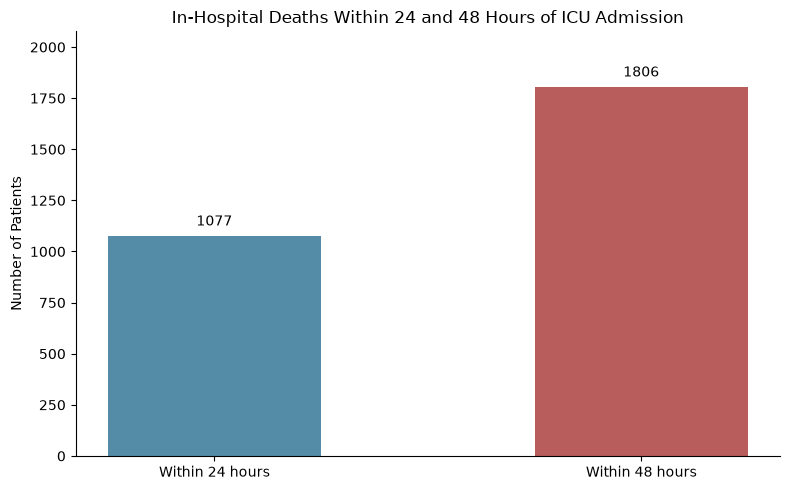

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Add death timestamps to adult ICU stays
mortality_df = adult_icu_df.merge(
    admissions_df[["SUBJECT_ID", "HADM_ID", "DEATHTIME"]],
    on=["SUBJECT_ID", "HADM_ID"],
    how="left",
    validate="many_to_one"
)

# Convert timestamp columns to datetime
mortality_df["INTIME"] = pd.to_datetime(mortality_df["INTIME"])
mortality_df["DEATHTIME"] = pd.to_datetime(mortality_df["DEATHTIME"])

# Calculate hours from ICU admission to death
mortality_df["hours_to_death"] = (
    mortality_df["DEATHTIME"] - mortality_df["INTIME"]
).dt.total_seconds() / 3600

# Count each patient only once within each time window
deaths_24h = mortality_df.loc[
    mortality_df["hours_to_death"].between(0, 24),
    "SUBJECT_ID"
].nunique()

deaths_48h = mortality_df.loc[
    mortality_df["hours_to_death"].between(0, 48),
    "SUBJECT_ID"
].nunique()

print("Patients who died within 24 hours of ICU admission:", deaths_24h)
print("Patients who died within 48 hours of ICU admission:", deaths_48h)

# The 48-hour total includes deaths within the first 24 hours
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ["Within 24 hours", "Within 48 hours"],
    [deaths_24h, deaths_48h],
    color=["#548CA8", "#B85C5C"],
    width=0.5
)

ax.bar_label(bars, padding=5)
ax.set_title("In-Hospital Deaths Within 24 and 48 Hours of ICU Admission")
ax.set_ylabel("Number of Patients")
ax.set_ylim(0, max(deaths_24h, deaths_48h, 1) * 1.15)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Total adult ICU patients: 38,510
Mortality within 24 hours: 2.80%
Mortality within 48 hours: 4.69%


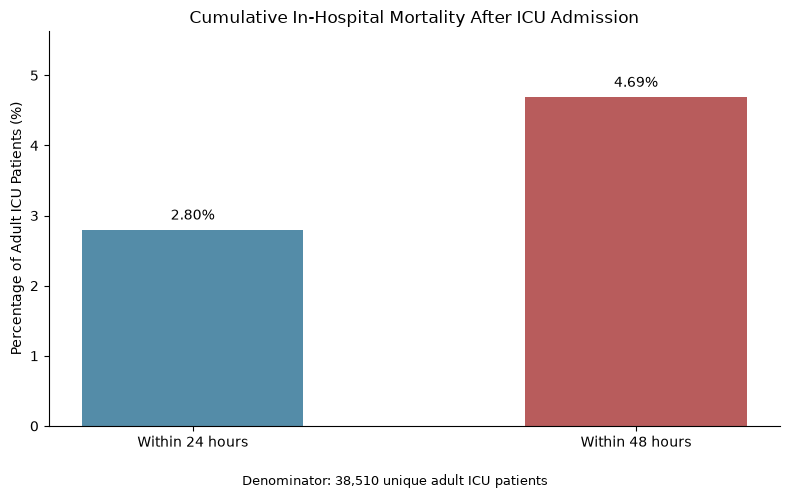

In [36]:
# Count unique patients in the adult ICU cohort
total_patients = adult_icu_df["SUBJECT_ID"].nunique()

# Calculate cumulative mortality percentages
mortality_24h = deaths_24h / total_patients * 100
mortality_48h = deaths_48h / total_patients * 100

print(f"Total adult ICU patients: {total_patients:,}")
print(f"Mortality within 24 hours: {mortality_24h:.2f}%")
print(f"Mortality within 48 hours: {mortality_48h:.2f}%")

# Both percentages use the same denominator
# The 48-hour percentage includes deaths within 24 hours
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ["Within 24 hours", "Within 48 hours"],
    [mortality_24h, mortality_48h],
    color=["#548CA8", "#B85C5C"],
    width=0.5
)

ax.bar_label(
    bars,
    labels=[f"{mortality_24h:.2f}%", f"{mortality_48h:.2f}%"],
    padding=5
)

ax.set_title("Cumulative In-Hospital Mortality After ICU Admission")
ax.set_ylabel("Percentage of Adult ICU Patients (%)")
ax.set_ylim(0, max(mortality_24h, mortality_48h, 1) * 1.2)
ax.spines[["top", "right"]].set_visible(False)

fig.text(
    0.5, 0.02,
    f"Denominator: {total_patients:,} unique adult ICU patients",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### Early Mortality After ICU Admission

To examine early mortality, we added the death timestamp (`DEATHTIME`) from the admissions table to the adult ICU dataset, matching records by `SUBJECT_ID` and `HADM_ID`.

We calculated the time between ICU admission (`INTIME`) and death in hours, then counted unique patients with a recorded in-hospital death within 24 and 48 hours of ICU admission.

The analysis used the adult cohort before applying minimum 24-hour or 48-hour ICU stay filters, so early deaths were retained. Each patient was counted only once within each time window.

| Time Window | Patients Who Died | Percentage of Adult Patients |
|---|---:|---:|
| Within 24 hours | 1,077 | 2.80% |
| Within 48 hours | 1,806 | 4.69% |

Both percentages used the same denominator: **38,510 unique adult ICU patients**. Bar charts displayed the patient counts and percentages.

These windows are cumulative: deaths within 24 hours are also included in the 48-hour total. For patients with multiple ICU stays, a qualifying death could be identified relative to any recorded ICU admission, not only their first.

These results describe recorded in-hospital deaths following ICU admission; they do not require death to have occurred inside the ICU. This is a descriptive analysis, separate from the prediction task.

In [37]:
from pathlib import Path
import pandas as pd

data_path = Path(
    "/mnt/c/Users/vetts/Downloads/MimicIII/"
    "mimic-iii-clinical-database-1.4"
)

for file_path in sorted(data_path.rglob("*.csv")):
    if file_path.is_file():
        columns = pd.read_csv(file_path, nrows=0).columns.tolist()
        size_mb = file_path.stat().st_size / (1024 ** 2)

        print(f"\nTable: {file_path.name}")
        print(f"Size: {size_mb:,.1f} MB")
        print(f"Columns: {', '.join(columns)}")


Table: ADMISSIONS.csv
Size: 12.0 MB
Columns: ROW_ID, SUBJECT_ID, HADM_ID, ADMITTIME, DISCHTIME, DEATHTIME, ADMISSION_TYPE, ADMISSION_LOCATION, DISCHARGE_LOCATION, INSURANCE, LANGUAGE, RELIGION, MARITAL_STATUS, ETHNICITY, EDREGTIME, EDOUTTIME, DIAGNOSIS, HOSPITAL_EXPIRE_FLAG, HAS_CHARTEVENTS_DATA

Table: CALLOUT.csv
Size: 6.0 MB
Columns: ROW_ID, SUBJECT_ID, HADM_ID, SUBMIT_WARDID, SUBMIT_CAREUNIT, CURR_WARDID, CURR_CAREUNIT, CALLOUT_WARDID, CALLOUT_SERVICE, REQUEST_TELE, REQUEST_RESP, REQUEST_CDIFF, REQUEST_MRSA, REQUEST_VRE, CALLOUT_STATUS, CALLOUT_OUTCOME, DISCHARGE_WARDID, ACKNOWLEDGE_STATUS, CREATETIME, UPDATETIME, ACKNOWLEDGETIME, OUTCOMETIME, FIRSTRESERVATIONTIME, CURRENTRESERVATIONTIME

Table: CAREGIVERS.csv
Size: 0.2 MB
Columns: ROW_ID, CGID, LABEL, DESCRIPTION

Table: CHARTEVENTS.csv
Size: 33,672.2 MB
Columns: ROW_ID, SUBJECT_ID, HADM_ID, ICUSTAY_ID, ITEMID, CHARTTIME, STORETIME, CGID, VALUE, VALUENUM, VALUEUOM, WARNING, ERROR, RESULTSTATUS, STOPPED

Table: CPTEVENTS.csv
Size:

In [38]:
clinical_items_df = pd.read_csv(
    data_path / "D_ITEMS.csv" / "D_ITEMS.csv"
)

lab_items_df = pd.read_csv(
    data_path / "D_LABITEMS.csv" / "D_LABITEMS.csv"
)

display(clinical_items_df.head())
display(lab_items_df.head())

,ROW_ID,ITEMID,LABEL,ABBREVIATION,DBSOURCE,LINKSTO,CATEGORY,UNITNAME,PARAM_TYPE,CONCEPTID
0,457,497,Patient controlled analgesia (PCA) [Inject],NaN,carevue,chartevents,NaN,NaN,NaN,NaN
1,458,498,PCA Lockout (Min),NaN,carevue,chartevents,NaN,NaN,NaN,NaN
2,459,499,PCA Medication,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
3,460,500,PCA Total Dose,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
4,461,501,PCV Exh Vt (Obser),NaN,carevue,chartevents,NaN,NaN,NaN,NaN


,ROW_ID,ITEMID,LABEL,FLUID,CATEGORY,LOINC_CODE
0,546,51346,Blasts,Cerebrospinal Fluid (CSF),Hematology,26447-3
1,547,51347,Eosinophils,Cerebrospinal Fluid (CSF),Hematology,26451-5
2,548,51348,"Hematocrit, CSF",Cerebrospinal Fluid (CSF),Hematology,30398-2
3,549,51349,Hypersegmented Neutrophils,Cerebrospinal Fluid (CSF),Hematology,26506-6
4,550,51350,Immunophenotyping,Cerebrospinal Fluid (CSF),Hematology,NaN


In [39]:
lab_results_sample_df = pd.read_csv(
    data_path / "LABEVENTS.csv" / "LABEVENTS.csv",
    nrows=5
)

display(lab_results_sample_df)

,ROW_ID,SUBJECT_ID,HADM_ID,ITEMID,CHARTTIME,VALUE,VALUENUM,VALUEUOM,FLAG
0,281,3,NaN,50820,2101-10-12 16:07:00,7.39,7.39,units,NaN
1,282,3,NaN,50800,2101-10-12 18:17:00,ART,NaN,NaN,NaN
2,283,3,NaN,50802,2101-10-12 18:17:00,-1,-1.00,mEq/L,NaN
3,284,3,NaN,50804,2101-10-12 18:17:00,22,22.00,mEq/L,NaN
4,285,3,NaN,50808,2101-10-12 18:17:00,0.93,0.93,mmol/L,abnormal


In [40]:
lab_results_sample_df = lab_results_sample_df.merge(
    lab_items_df[["ITEMID", "LABEL", "FLUID", "CATEGORY"]],
    on="ITEMID",
    how="left",
    validate="many_to_one"
)

display(
    lab_results_sample_df[
        ["SUBJECT_ID", "ITEMID", "LABEL", "FLUID",
         "CHARTTIME", "VALUE", "VALUEUOM"]
    ]
)

,SUBJECT_ID,ITEMID,LABEL,FLUID,CHARTTIME,VALUE,VALUEUOM
0,3,50820,pH,Blood,2101-10-12 16:07:00,7.39,units
1,3,50800,SPECIMEN TYPE,BLOOD,2101-10-12 18:17:00,ART,NaN
2,3,50802,Base Excess,Blood,2101-10-12 18:17:00,-1,mEq/L
3,3,50804,Calculated Total CO2,Blood,2101-10-12 18:17:00,22,mEq/L
4,3,50808,Free Calcium,Blood,2101-10-12 18:17:00,0.93,mmol/L


In [41]:
print(lab_items_df["LABEL"].unique())

<ArrowStringArray>
[                    'Blasts',                'Eosinophils',
            'Hematocrit, CSF', 'Hypersegmented Neutrophils',
          'Immunophenotyping',                     'Lymphs',
                 'Macrophage',          'Mesothelial cells',
             'Metamyelocytes',                  'Monocytes',
 ...
   'Estimated Actual Glucose',                     'AF-AFP',
                  'STDYURINE',                    'PLASMGN',
                       'WBCP',                     'MYELOS',
                        'TDT',           'PROBLEM SPECIMEN',
            'VOIDED SPECIMEN',   'SURFACTANT ALBUMIN RATIO']
Length: 589, dtype: str


In [42]:
labevents_df = pd.read_csv(
    data_path / "LABEVENTS.csv" / "LABEVENTS.csv",
    parse_dates=["CHARTTIME"]
)

In [43]:
labevents_df["CHARTTIME"].dtype

dtype('<M8[us]')

In [44]:
lab_test_counts = (
    labevents_df.groupby("ITEMID")["SUBJECT_ID"]
    .nunique()
    .reset_index(name="patient_count")
)

lab_test_counts.head()

,ITEMID,patient_count
0,50800,23819
1,50801,9399
2,50802,31427
3,50803,7144
4,50804,31427


In [45]:
lab_test_counts["ITEMID"].nunique()

726

In [46]:
short_stay_df = adult_icu_df[adult_icu_df["LOS"] < 1]

print("ICU stays shorter than 24 hours:", len(short_stay_df))

print(
    short_stay_df["HOSPITAL_EXPIRE_FLAG"].value_counts()
)

ICU stays shorter than 24 hours: 8076
HOSPITAL_EXPIRE_FLAG
0    6902
1    1174
Name: count, dtype: int64


In [47]:
long_stay_df = adult_icu_df[adult_icu_df["LOS"] >= 1]

print("ICU stays of at least 24 hours:", len(long_stay_df))

ICU stays of at least 24 hours: 45253


In [48]:
print(
    long_stay_df["HOSPITAL_EXPIRE_FLAG"].value_counts()
)

HOSPITAL_EXPIRE_FLAG
0    39893
1     5360
Name: count, dtype: int64


In [49]:
adult_icu_24h_df = adult_icu_df[adult_icu_df["LOS"] >= 1].copy()

print(adult_icu_24h_df.shape)

(45253, 16)


## Filtering ICU Stays by Minimum 24-Hour Length of Stay

Since the goal of the project is to predict mortality using the first 24 hours of ICU data, patients with ICU stays shorter than 24 hours were examined separately.

Among adult ICU records:

- 8,076 ICU stays were shorter than 24 hours.
- 6,902 of these patients survived.
- 1,174 died in the hospital.

For ICU stays of at least 24 hours:

- 45,253 records remained.
- 39,893 patients survived.
- 5,360 died in the hospital.

To ensure that every patient has a complete 24-hour observation window, ICU stays shorter than 24 hours were excluded from the main analysis.

The filtered adult ICU dataset contains:

- 45,253 rows
- 16 columns

This filtered dataset will be used for the next stages of laboratory and clinical feature selection.

In [50]:
adult_icu_24h_df.columns

Index(['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'INTIME', 'OUTTIME',
       'FIRST_CAREUNIT', 'LOS', 'GENDER', 'DOB', 'ADMITTIME', 'DISCHTIME',
       'ADMISSION_TYPE', 'HOSPITAL_EXPIRE_FLAG', 'AGE_RAW', 'AGE_90_PLUS',
       'AGE'],
      dtype='str')

In [51]:
labevents_df.columns

Index(['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'ITEMID', 'CHARTTIME', 'VALUE',
       'VALUENUM', 'VALUEUOM', 'FLAG'],
      dtype='str')

In [52]:
target_labevents_df = labevents_df[
    labevents_df["HADM_ID"].isin(adult_icu_24h_df["HADM_ID"])
].copy()

print(target_labevents_df.shape)

(20166734, 9)


In [53]:
lab_test_frequency = (
    target_labevents_df.groupby("ITEMID")["HADM_ID"]
    .nunique()
    .reset_index(name="admission_count")
)

lab_test_frequency = lab_test_frequency.sort_values(
    "admission_count",
    ascending=False
)

lab_test_frequency.head(20)

,ITEMID,admission_count
108,50912,42200
196,51006,42200
407,51221,42198
450,51265,42197
486,51301,42189
408,51222,42188
436,51250,42187
464,51279,42187
435,51249,42187
434,51248,42187


In [54]:
common_lab_tests = lab_test_frequency[
    lab_test_frequency["admission_count"] >= 22627
]

print("Number of lab tests present in at least 50% of ICU stays:", len(common_lab_tests))

Number of lab tests present in at least 50% of ICU stays: 60


In [55]:
common_lab_tests_named = common_lab_tests.merge(
    lab_items_df[["ITEMID", "LABEL", "FLUID", "CATEGORY"]],
    on="ITEMID",
    how="left"
)

common_lab_tests_named.head(60)

,ITEMID,admission_count,LABEL,FLUID,CATEGORY
0,50912,42200,Creatinine,Blood,Chemistry
1,51006,42200,Urea Nitrogen,Blood,Chemistry
2,51221,42198,Hematocrit,Blood,Hematology
3,51265,42197,Platelet Count,Blood,Hematology
4,51301,42189,White Blood Cells,Blood,Hematology
5,51222,42188,Hemoglobin,Blood,Hematology
6,51250,42187,MCV,Blood,Hematology
7,51279,42187,Red Blood Cells,Blood,Hematology
8,51249,42187,MCHC,Blood,Hematology
9,51248,42187,MCH,Blood,Hematology


In [56]:
selected_lab_names = [
    "Creatinine",
    "Urea Nitrogen",
    "Hemoglobin",
    "Platelet Count",
    "White Blood Cells",
    "Sodium",
    "Potassium",
    "Chloride",
    "Bicarbonate",
    "Anion Gap",
    "Glucose",
    "Magnesium",
    "Calcium, Total",
    "Phosphate",
    "INR(PT)",
    "pH",
    "pO2",
    "pCO2",
    "Lactate",
    "Albumin",
    "Bilirubin, Total",
    "Asparate Aminotransferase (AST)",
    "Alanine Aminotransferase (ALT)"
]

selected_lab_tests = common_lab_tests_named[
    common_lab_tests_named["LABEL"].isin(selected_lab_names)
].copy()

selected_lab_tests

,ITEMID,admission_count,LABEL,FLUID,CATEGORY
0,50912,42200,Creatinine,Blood,Chemistry
1,51006,42200,Urea Nitrogen,Blood,Chemistry
3,51265,42197,Platelet Count,Blood,Hematology
4,51301,42189,White Blood Cells,Blood,Hematology
5,51222,42188,Hemoglobin,Blood,Hematology
11,50971,42177,Potassium,Blood,Chemistry
12,50902,42171,Chloride,Blood,Chemistry
13,50882,42170,Bicarbonate,Blood,Chemistry
14,50983,42170,Sodium,Blood,Chemistry
15,50868,42165,Anion Gap,Blood,Chemistry


In [57]:
selected_lab_tests = selected_lab_tests[
    ~(
        (selected_lab_tests["LABEL"] == "pH") &
        (selected_lab_tests["FLUID"] != "Blood")
    )
]

selected_lab_tests = selected_lab_tests[
    ~(
        (selected_lab_tests["LABEL"] == "Glucose") &
        ~(
            (selected_lab_tests["FLUID"] == "Blood") &
            (selected_lab_tests["CATEGORY"] == "Chemistry")
        )
    )
]

selected_lab_tests

,ITEMID,admission_count,LABEL,FLUID,CATEGORY
0,50912,42200,Creatinine,Blood,Chemistry
1,51006,42200,Urea Nitrogen,Blood,Chemistry
3,51265,42197,Platelet Count,Blood,Hematology
4,51301,42189,White Blood Cells,Blood,Hematology
5,51222,42188,Hemoglobin,Blood,Hematology
11,50971,42177,Potassium,Blood,Chemistry
12,50902,42171,Chloride,Blood,Chemistry
13,50882,42170,Bicarbonate,Blood,Chemistry
14,50983,42170,Sodium,Blood,Chemistry
15,50868,42165,Anion Gap,Blood,Chemistry


In [58]:
selected_labevents_df = target_labevents_df[
    target_labevents_df["ITEMID"].isin(selected_lab_tests["ITEMID"])
].copy()

print(selected_labevents_df.shape)

(9978641, 9)


In [59]:
icu_stays_per_admission = (
    adult_icu_24h_df.groupby("HADM_ID")["ICUSTAY_ID"]
    .nunique()
)

multiple_icu_admissions = icu_stays_per_admission[
    icu_stays_per_admission > 1
]

print("Admissions with more than one ICU stay:", len(multiple_icu_admissions))

Admissions with more than one ICU stay: 2399


In [60]:
print(adult_icu_24h_df["INTIME"].dtype)
print(selected_labevents_df["CHARTTIME"].dtype)

datetime64[us]
datetime64[us]


In [61]:
icu_map_df = adult_24h_df[
    ["HADM_ID", "ICUSTAY_ID", "INTIME"]
].copy()

In [62]:
chunk_size = 500_000
first_24h_chunks = []

for start in range(0, len(selected_labevents_df), chunk_size):
    lab_chunk = selected_labevents_df.iloc[start:start + chunk_size][
        ["HADM_ID", "ITEMID", "CHARTTIME", "VALUENUM", "VALUEUOM"]
    ].copy()

    merged_chunk = lab_chunk.merge(
        icu_map_df,
        on="HADM_ID",
        how="inner"
    )

    first_24h_chunk = merged_chunk[
        (merged_chunk["CHARTTIME"] >= merged_chunk["INTIME"]) &
        (merged_chunk["CHARTTIME"] < merged_chunk["INTIME"] + pd.Timedelta(hours=24))
    ].copy()

    first_24h_chunks.append(first_24h_chunk)

lab_first_24h_df = pd.concat(first_24h_chunks, ignore_index=True)

print(lab_first_24h_df.shape)

(1735994, 7)


In [63]:
lab_first_24h_df.head()

,HADM_ID,ITEMID,CHARTTIME,VALUENUM,VALUEUOM,ICUSTAY_ID,INTIME
0,145834.0,51006,2101-10-20 19:26:00,41.0,mg/dL,211552,2101-10-20 19:10:11
1,145834.0,51222,2101-10-20 19:26:00,7.8,g/dL,211552,2101-10-20 19:10:11
2,145834.0,51237,2101-10-20 19:26:00,1.7,NaN,211552,2101-10-20 19:10:11
3,145834.0,51265,2101-10-20 19:26:00,190.0,K/uL,211552,2101-10-20 19:10:11
4,145834.0,51301,2101-10-20 19:26:00,11.3,K/uL,211552,2101-10-20 19:10:11


## Laboratory Feature Selection and First 24-Hour Extraction

### 1. Defining the Main Prediction Scope

The current project scope was narrowed to **hospital mortality prediction**.

Although the dataset can also support future projects such as:

- Sepsis prediction
- Acute kidney injury / renal failure prediction
- Cardiac event prediction

these outcomes will be handled as separate future projects to keep the current analysis focused and manageable.

---

### 2. Restricting LABEVENTS to the Target ICU Cohort

The laboratory dataset was restricted to hospital admissions belonging to the previously defined adult ICU cohort with stays of at least 24 hours.

After filtering, the laboratory dataset contained:

- **20,166,734 laboratory records**

This ensured that laboratory feature selection was based only on the population that will actually be used in the mortality model.

---

### 3. Measuring Laboratory Test Frequency

For each laboratory test, the number of unique hospital admissions in which the test was performed was calculated.

The tests were then ranked from the most common to the least common.

A frequency threshold of **50% of the target ICU admissions** was used as an initial screening criterion.

Since the target cohort contains 45,253 ICU stays, the approximate 50% threshold was:

- **22,627 admissions**

Using this threshold reduced the laboratory test pool from approximately **726 ITEMIDs to 60 commonly performed tests**.

---

### 4. Reviewing the 60 Most Common Laboratory Tests

The 60 common laboratory ITEMIDs were matched with the laboratory dictionary to obtain:

- Test name
- Specimen type
- Laboratory category

This allowed clinically irrelevant, duplicated or overly specific variables to be removed.

Several urine-based tests and redundant hematological indices were excluded.

Examples of excluded variables included:

- Urine Color
- Urine Appearance
- Yeast
- Epithelial Cells
- MCV
- MCH
- MCHC
- RDW

When multiple variables provided very similar information, the more clinically useful or general variable was preferred.

Examples:

- Hemoglobin was preferred over Hematocrit and RBC count.
- INR was retained while PT and PTT were removed.
- Chemistry Glucose was retained instead of urine or blood-gas glucose.
- Standard Potassium was retained instead of whole-blood potassium.
- Blood pH was retained instead of urine pH.
- Total Calcium was retained instead of Free Calcium.
- Bicarbonate and Anion Gap were retained while Base Excess was excluded.

AST and ALT were both retained because they may provide complementary information about liver injury and overall disease severity.

---

### 5. Final Laboratory Candidate Set

A final set of **23 laboratory features** was selected for mortality prediction:

- Creatinine
- Urea Nitrogen
- Hemoglobin
- Platelet Count
- White Blood Cells
- Sodium
- Potassium
- Chloride
- Bicarbonate
- Anion Gap
- Glucose
- Magnesium
- Calcium, Total
- Phosphate
- INR(PT)
- Blood pH
- pO2
- pCO2
- Lactate
- Albumin
- Bilirubin, Total
- AST
- ALT

These variables were selected based on a combination of:

- Frequency
- Clinical relevance
- Redundancy reduction
- Suitability for early mortality prediction

---

### 6. Extracting Real Measurements for the Selected Tests

The selected 23 laboratory test codes were used to filter the laboratory event table.

This produced:

- **9,978,641 laboratory records**

At this stage, the dataset contained only real measurements belonging to the selected laboratory tests.

---

### 7. Handling Multiple ICU Stays Within the Same Hospital Admission

A single hospital admission can contain more than one ICU stay.

This was checked explicitly.

Result:

- **2,399 hospital admissions had more than one ICU stay**

Because LABEVENTS contains hospital admission IDs but not ICU stay IDs, laboratory records cannot be directly assigned to a specific ICU stay using IDs alone.

Therefore, ICU timing information was used to connect laboratory measurements with the correct ICU stay.

---

### 8. Preparing ICU Timing Information

A lightweight ICU mapping table was created containing only:

- Hospital admission ID
- ICU stay ID
- ICU admission time

The resulting mapping table contained:

- **45,253 rows**
- **3 columns**

This smaller helper table was created to reduce memory usage during the laboratory-ICU matching process.

---

### 9. Improving Datetime Handling

The laboratory timestamp column initially required conversion from text to datetime.

Because the selected laboratory dataset contained nearly 10 million rows, converting the entire column after loading caused excessive memory pressure.

To avoid this issue, the laboratory file was reloaded with the timestamp parsed directly as datetime during file reading.

This reduced the need for a large post-loading datetime conversion step.

---

### 10. Memory-Efficient ICU Matching and First 24-Hour Filtering

A direct merge between the nearly 10-million-row laboratory table and the ICU mapping table caused memory instability.

To avoid this, the laboratory data was processed in **chunks of 500,000 rows**.

For each chunk:

1. Laboratory records were matched with ICU information using the hospital admission ID.
2. The laboratory measurement time was compared with the ICU admission time.
3. Only measurements occurring between ICU admission and the following 24 hours were retained.
4. The filtered chunks were concatenated back into a single dataframe.

Chunking was used only as a memory-management technique. No part of the dataset was intentionally excluded.

The resulting first-24-hour laboratory dataset contained:

- **1,735,994 rows**
- **7 columns**

---

### 11. Current Laboratory Dataset Structure

The current laboratory dataset is still in **long format**.

This means that:

- One row represents one laboratory measurement.
- The same ICU stay can appear in multiple rows.
- Different laboratory tests for the same patient are currently stored vertically.

Example structure:

- ICU stay
- Laboratory test code
- Measurement time
- Laboratory value

The next step will be to decide how repeated measurements of the same test within the first 24 hours should be summarized before converting the dataset into a patient-level wide feature table.

In [64]:
lab_first_24h_df = lab_first_24h_df.sort_values(
    ["ICUSTAY_ID", "ITEMID", "CHARTTIME"]
)

In [65]:
lab_first_last_df = (
    lab_first_24h_df
    .groupby(["ICUSTAY_ID", "ITEMID"])["VALUENUM"]
    .agg(first_value="first", last_value="last")
    .reset_index()
)

lab_first_last_df.head()

,ICUSTAY_ID,ITEMID,first_value,last_value
0,200001,50813,1.40,1.4
1,200001,50818,43.00,40.0
2,200001,50820,7.41,7.4
3,200001,50821,79.00,114.0
4,200001,50861,6.00,6.0


In [66]:
lab_first_last_named_df = lab_first_last_df.merge(
    selected_lab_tests[["ITEMID", "LABEL"]],
    on="ITEMID",
    how="left"
)

lab_first_last_named_df.head()

,ICUSTAY_ID,ITEMID,first_value,last_value,LABEL
0,200001,50813,1.40,1.4,Lactate
1,200001,50818,43.00,40.0,pCO2
2,200001,50820,7.41,7.4,pH
3,200001,50821,79.00,114.0,pO2
4,200001,50861,6.00,6.0,Alanine Aminotransferase (ALT)


In [67]:
lab_wide_df = lab_first_last_named_df.pivot(
    index="ICUSTAY_ID",
    columns="LABEL",
    values=["first_value", "last_value"]
)

lab_wide_df.head()

first_value                    \
LABEL      Alanine Aminotransferase (ALT) Albumin Anion Gap   
ICUSTAY_ID                                                    
200001                                6.0     NaN      14.0   
200003                               62.0     2.8      21.0   
200006                                NaN     NaN      12.0   
200007                                NaN     4.0      17.0   
200009                                NaN     NaN      11.0   

                                                                         \
LABEL      Asparate Aminotransferase (AST) Bicarbonate Bilirubin, Total   
ICUSTAY_ID                                                                
200001                                29.0        28.0              0.2   
200003                                49.0        18.0              3.4   
200006                                 NaN        31.0              NaN   
200007                                 NaN        22.0              NaN   
200009                                 NaN        24.0              NaN   

                                                       ... last_value  \
LABEL      Calcium, Total Chloride Creatinine Glucose  ...  Magnesium   
ICUSTAY_ID                                             ...              
200001                8.5    101.0        2.7    87.0  ...        2.0   
200003                7.7    105.0        1.0   159.0  ...        2.5   
200006                8.2     98.0        0.8    71.0  ...        1.6   
200007                8.9    103.0        0.8   233.0  ...        1.8   
200009                NaN    113.0        0.5    91.0  ...        NaN   

                                                                    \
LABEL      Phosphate Platelet Count Potassium Sodium Urea Nitrogen   
ICUSTAY_ID                                                           
200001           5.0          128.0       4.3  139.0          83.0   
200003           3.5          119.0       3.1  144.0          19.0   
200006           3.0          162.0       3.5  137.0          14.0   
200007           2.4          247.0       3.9  135.0           8.0   
200009           NaN           81.0       3.9  143.0          16.0   

                                                 
LABEL      White Blood Cells  pCO2    pH    pO2  
ICUSTAY_ID                                       
200001                   2.8  40.0  7.40  114.0  
200003                  43.9  43.0  7.41  163.0  
200006                   4.2   NaN   NaN    NaN  
200007                  11.2   NaN   NaN    NaN  
200009                  11.5  42.0  7.32   94.0  

[5 rows x 46 columns]

In [68]:
lab_wide_df.columns = [
    f"{test}_{value_type.replace('_value', '')}"
    for value_type, test in lab_wide_df.columns
]

lab_wide_df = lab_wide_df.reset_index()

lab_wide_df.head()

,ICUSTAY_ID,Alanine Aminotransferase (ALT)_first,Albumin_first,Anion Gap_first,Asparate Aminotransferase (AST)_first,Bicarbonate_first,"Bilirubin, Total_first","Calcium, Total_first",Chloride_first,Creatinine_first,...,Magnesium_last,Phosphate_last,Platelet Count_last,Potassium_last,Sodium_last,Urea Nitrogen_last,White Blood Cells_last,pCO2_last,pH_last,pO2_last
0,200001,6.0,NaN,14.0,29.0,28.0,0.2,8.5,101.0,2.7,...,2.0,5.0,128.0,4.3,139.0,83.0,2.8,40.0,7.40,114.0
1,200003,62.0,2.8,21.0,49.0,18.0,3.4,7.7,105.0,1.0,...,2.5,3.5,119.0,3.1,144.0,19.0,43.9,43.0,7.41,163.0
2,200006,NaN,NaN,12.0,NaN,31.0,NaN,8.2,98.0,0.8,...,1.6,3.0,162.0,3.5,137.0,14.0,4.2,NaN,NaN,NaN
3,200007,NaN,4.0,17.0,NaN,22.0,NaN,8.9,103.0,0.8,...,1.8,2.4,247.0,3.9,135.0,8.0,11.2,NaN,NaN,NaN
4,200009,NaN,NaN,11.0,NaN,24.0,NaN,NaN,113.0,0.5,...,NaN,NaN,81.0,3.9,143.0,16.0,11.5,42.0,7.32,94.0


In [ ]:
for col in lab_wide_df.columns:
    if col.endswith("_first"):
        test_name = col.replace("_first", "")
        last_col = f"{test_name}_last"

        if last_col in lab_wide_df.columns:
            lab_wide_df[f"{test_name}_change"] = (
                lab_wide_df[last_col] - lab_wide_df[col]
            )

In [70]:
tests = [
    col.replace("_first", "")
    for col in lab_wide_df.columns
    if col.endswith("_first")
]

ordered_columns = ["ICUSTAY_ID"]

for test in tests:
    ordered_columns.extend([
        f"{test}_first",
        f"{test}_change"
    ])

lab_wide_df = lab_wide_df[ordered_columns]

lab_wide_df.head()

,ICUSTAY_ID,Alanine Aminotransferase (ALT)_first,Alanine Aminotransferase (ALT)_change,Albumin_first,Albumin_change,Anion Gap_first,Anion Gap_change,Asparate Aminotransferase (AST)_first,Asparate Aminotransferase (AST)_change,Bicarbonate_first,...,Urea Nitrogen_first,Urea Nitrogen_change,White Blood Cells_first,White Blood Cells_change,pCO2_first,pCO2_change,pH_first,pH_change,pO2_first,pO2_change
0,200001,6.0,0.0,NaN,NaN,14.0,0.0,29.0,0.0,28.0,...,83.0,0.0,2.8,0.0,43.0,-3.0,7.41,-0.01,79.0,35.0
1,200003,62.0,-14.0,2.8,0.0,21.0,-6.0,49.0,-6.0,18.0,...,20.0,-1.0,40.2,3.7,34.0,9.0,7.36,0.05,88.0,75.0
2,200006,NaN,NaN,NaN,NaN,12.0,0.0,NaN,NaN,31.0,...,14.0,0.0,4.1,0.1,NaN,NaN,NaN,NaN,NaN,NaN
3,200007,NaN,NaN,4.0,0.0,17.0,-3.0,NaN,NaN,22.0,...,10.0,-2.0,11.2,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,200009,NaN,NaN,NaN,NaN,11.0,0.0,NaN,NaN,24.0,...,15.0,1.0,11.0,0.5,40.0,2.0,7.46,-0.14,437.0,-343.0


In [71]:
missing_percent = (
    lab_wide_df.isna().mean() * 100
).sort_values(ascending=False)

missing_percent

Albumin_first                             72.177654
Albumin_change                            72.177654
Bilirubin, Total_change                   64.677542
Bilirubin, Total_first                    64.677542
Asparate Aminotransferase (AST)_first     64.502756
Asparate Aminotransferase (AST)_change    64.502756
Alanine Aminotransferase (ALT)_first      64.480348
Alanine Aminotransferase (ALT)_change     64.480348
Lactate_first                             54.102989
Lactate_change                            54.102989
pO2_first                                 40.167167
pO2_change                                40.167167
pCO2_change                               40.167167
pCO2_first                                40.167167
pH_change                                 37.617084
pH_first                                  37.617084
INR(PT)_first                             19.533456
INR(PT)_change                            19.533456
Calcium, Total_first                      15.773316
Calcium, Tot

In [72]:
drop_tests = [
    "Alanine Aminotransferase (ALT)",
    "Asparate Aminotransferase (AST)",
    "Bilirubin, Total",
    "Albumin"
]

columns_to_drop = []

for test in drop_tests:
    columns_to_drop.extend([
        f"{test}_first",
        f"{test}_change"
    ])

lab_wide_df = lab_wide_df.drop(columns=columns_to_drop)

lab_wide_df.head()

,ICUSTAY_ID,Anion Gap_first,Anion Gap_change,Bicarbonate_first,Bicarbonate_change,"Calcium, Total_first","Calcium, Total_change",Chloride_first,Chloride_change,Creatinine_first,...,Urea Nitrogen_first,Urea Nitrogen_change,White Blood Cells_first,White Blood Cells_change,pCO2_first,pCO2_change,pH_first,pH_change,pO2_first,pO2_change
0,200001,14.0,0.0,28.0,0.0,8.5,0.0,101.0,0.0,2.7,...,83.0,0.0,2.8,0.0,43.0,-3.0,7.41,-0.01,79.0,35.0
1,200003,21.0,-6.0,18.0,7.0,7.7,0.6,105.0,2.0,1.0,...,20.0,-1.0,40.2,3.7,34.0,9.0,7.36,0.05,88.0,75.0
2,200006,12.0,0.0,31.0,0.0,8.2,0.0,98.0,0.0,0.8,...,14.0,0.0,4.1,0.1,NaN,NaN,NaN,NaN,NaN,NaN
3,200007,17.0,-3.0,22.0,2.0,8.9,0.0,103.0,-2.0,0.8,...,10.0,-2.0,11.2,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,200009,11.0,0.0,24.0,-3.0,NaN,NaN,113.0,2.0,0.5,...,15.0,1.0,11.0,0.5,40.0,2.0,7.46,-0.14,437.0,-343.0


In [73]:
print("Shape:", lab_wide_df.shape)

missing_percent = (
    lab_wide_df.isna().mean() * 100
).sort_values(ascending=False)

missing_percent

Shape: (44626, 39)


Lactate_first               54.102989
Lactate_change              54.102989
pO2_first                   40.167167
pO2_change                  40.167167
pCO2_change                 40.167167
pCO2_first                  40.167167
pH_change                   37.617084
pH_first                    37.617084
INR(PT)_first               19.533456
INR(PT)_change              19.533456
Calcium, Total_change       15.773316
Calcium, Total_first        15.773316
Phosphate_first             15.231031
Phosphate_change            15.231031
Magnesium_first              5.947206
Magnesium_change             5.947206
Glucose_first                3.289562
Glucose_change               3.289562
Anion Gap_first              3.069959
Anion Gap_change             3.069959
Potassium_change             2.290145
Potassium_first              2.290145
Hemoglobin_change            2.220679
Hemoglobin_first             2.220679
White Blood Cells_first      1.969704
White Blood Cells_change     1.969704
Platelet Cou

## Laboratory Feature Engineering Notes

- The first 24-hour laboratory data was converted from long format to one row per ICU stay.
- For each selected laboratory test, the first and last measurements were identified.
- Instead of keeping the last value directly, a change feature was created:

  **change = last value - first value**

- Final lab structure uses:
  - `Test_first`
  - `Test_change`

- Highly missing liver-related features were removed:
  - AST
  - ALT
  - Bilirubin
  - Albumin

- Lactate, pH, pO2 and pCO2 were retained despite higher missingness because of their clinical relevance.

- Final laboratory table shape:
  - **44,626 ICU stays**
  - **39 columns**

- The original target cohort had 45,253 ICU stays, so **627 ICU stays had no usable selected laboratory measurements in the first 24 hours**.

These 627 ICU stays were not removed yet. They may still contain useful information from other clinical data sources.